# Pandas with EDA
-----------------------

note: please copy the codes from here into your notebook , for quick learning experience and avoid mistakes.

🏀 NBA
--------------------------------------
URL: https://drive.google.com/file/d/1ZaNh_kZ5fIV7iXx350dDS2UbnSiJoRsD/view?usp=sharing

# Uploading Dataset
----------------
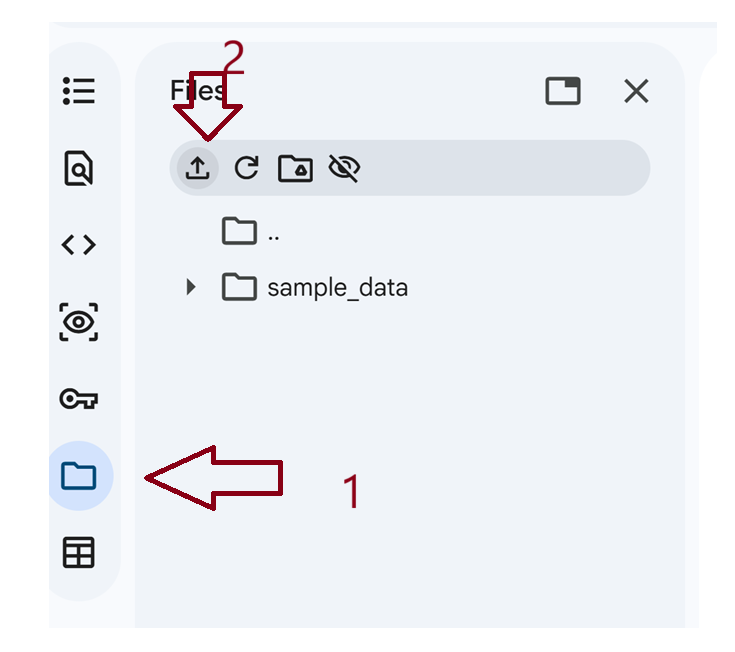

# Import pandas
----------------

In [ ]:
import pandas as pd

# Load DataFrame
----------------------------
pd.read_csv( filepath ): this is used to read CSV File Dataset and create Dataframe.

In [ ]:
nba = pd.read_csv('nba.csv')

In [ ]:
# use .head() to preview first 5 records
nba.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


# Exploratory Data Analysis
---------------------------------------

- 1 MetaData Inspection
-------------------------------------------------
this is the first routine structural check that we begin with.
in this we check for columns/datatypes/len/ etc.

In [ ]:
# Total Count of Records
len(nba)

458

In [ ]:
# Columns
print(  nba.columns.tolist() )

['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight', 'College', 'Salary']


In [ ]:
# DataType of Each Column
nba.dtypes

,0
Name,object
Team,object
Number,float64
Position,object
Age,float64
Height,object
Weight,float64
College,object
Salary,float64


.describe(): this returns the statistical facts about numerical Columns.

In [ ]:
nba.describe()

,Number,Age,Weight,Salary
count,457.000000,457.000000,457.000000,4.460000e+02
mean,17.678337,26.938731,221.522976,4.842684e+06
std,15.966090,4.404016,26.368343,5.229238e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.044792e+06
50%,13.000000,26.000000,220.000000,2.839073e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


# Target Column :  [AGE]
---------------------------------------------
- 1 COUNT : We Have Age Data Available for 457 Players.
- 2 MEAN  : Avg Age of player is around 26.93 i.e. 27 yrs.
- 3 STD   : Most of the Players are between the Age of
Mean - STD to Mean + STD years. i.e. 22.6 to 30.4
- 4 MIN   : Youngest Player is  19 years old.
- 5 Q1(25%): 25% of the players are younger than 24 yrs age.
- 6 Q2
- 7 Q3
- 8 Max : oldest player is 40 yrs old.

# .info()


In [ ]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      457 non-null    object 
 2   Number    457 non-null    float64
 3   Position  457 non-null    object 
 4   Age       457 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


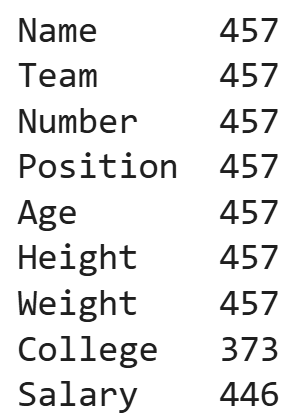

- which column is having the most missing values ?
answer: college

-- Find the Count of Missing values in each column.

In [ ]:
nba.isna().sum().sort_values(ascending=False)

,0
College,85
Salary,12
Name,1
Team,1
Number,1
Age,1
Position,1
Weight,1
Height,1


`College` is having 85 Missing values!

Task : you are asked to find the missing value in percentage.


this information will be used to decide whether to
- impute nulls
- delete rows containing nulls
- OR
- delete column

In [ ]:
(nba.College.isna().sum() / len(nba))*100

np.float64(18.5589519650655)

18% of Records contain NaN in College Column.

- would you dare to delete 18% Records from your Dataframe ?

- suggested solution: to impute the values.

# Activity; using .fillna() to impute
-----------
let us suppose we have decide to replace NaN in Salary column with Avg Salary.

In [ ]:
nba.Salary.isna().sum()

np.int64(12)

In [ ]:
nba[ nba.Salary.isna() ].head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
46,Elton Brand,Philadelphia 76ers,42.0,PF,37.0,6-9,254.0,Duke,NaN
171,Dahntay Jones,Cleveland Cavaliers,30.0,SG,35.0,6-6,225.0,Duke,NaN
264,Jordan Farmar,Memphis Grizzlies,4.0,PG,29.0,6-2,180.0,UCLA,NaN
269,Ray McCallum,Memphis Grizzlies,5.0,PG,24.0,6-3,190.0,Detroit,NaN


In [ ]:
# mean
nba.Salary.mean()

np.float64(4842684.105381166)

In [ ]:
nba.Salary.fillna( round(nba.Salary.mean(),2) , inplace=True)

In [ ]:
nba.Salary.isna().sum()

np.int64(0)

In [ ]:
import warnings
warnings.filterwarnings("ignore")


# Employees
------------------------------

https://drive.google.com/file/d/1Te9LhsDBgAjs0ZbFx8DnOtos45Izfm59/view?usp=sharing

In [ ]:
df = pd.read_csv('employees.csv')

In [ ]:
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


# Data Pre Processing
-------------------------------
1. Missing Value identification (df.isna().sum())
2. Missing value Treatment(putatimion) [ using .fillna() ]
3. DataType Correction (current Topic)


In [ ]:
df.dtypes

,0
First Name,object
Gender,object
Start Date,object
Last Login Time,object
Salary,int64
Bonus %,float64
Senior Management,object
Team,object


In [ ]:
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


In [ ]:
df[['Start Date','Last Login Time']].head(3)

,Start Date,Last Login Time
0,8/6/1993,12:42 PM
1,3/31/1996,6:53 AM
2,4/23/1993,11:17 AM


In [ ]:
df[['Start Date','Last Login Time']].dtypes

,0
Start Date,object
Last Login Time,object


DataType Correction is an import activity to be carried in data cleaning/pre processing.

In [ ]:
df['Start Date'] = pd.to_datetime(df ['Start Date'])

In [ ]:
df[['Start Date','Last Login Time']].dtypes

,0
Start Date,datetime64[ns]
Last Login Time,object


access to .dt object

In [ ]:
df['Start Date'].dt.year

,Start Date
0,1993
1,1996
2,1993
3,2005
4,1998
...,...
995,2014
996,1984
997,2013
998,2013


In [ ]:
# for what all years we have employees joining our firm.

print(df['Start Date'].dt.year.unique().tolist())

[1993, 1996, 2005, 1998, 1987, 2015, 2002, 1980, 1997, 2008, 1999, 2016, 2010, 1986, 1981, 1995, 2012, 1992, 2000, 1991, 2004, 2006, 2009, 1988, 2011, 1990, 2014, 2007, 2001, 2013, 2003, 1983, 1994, 1985, 1989, 1982, 1984]


In [ ]:
df['Last Login Time'].head(3)

,Last Login Time
0,12:42 PM
1,6:53 AM
2,11:17 AM


In [ ]:
df['Last Login Time'].dtype

dtype('O')

In [ ]:
df['Last Login Time'] = pd.to_datetime(df['Last Login Time'])

In [ ]:
df['Last Login Time'].dtype

dtype('<M8[ns]')

In [ ]:
print(df['Last Login Time'].dt.hour.unique().tolist())

[12, 6, 11, 13, 16, 1, 10, 9, 15, 23, 7, 5, 19, 3, 2, 22, 18, 14, 20, 4, 8, 17, 0, 21]


In [ ]:
# which is the most logged in hour !
print(df['Last Login Time'].dt.hour.mode())

0    13
Name: Last Login Time, dtype: int32


In [ ]:
# which is the most logged in hour !
print(df['Last Login Time'].dt.hour.mode()[0])

13


pd.to_datetime

In [ ]:
help(pd.to_datetime)

Help on function to_datetime in module pandas.core.tools.datetimes:

to_datetime(arg: 'DatetimeScalarOrArrayConvertible | DictConvertible', errors: 'DateTimeErrorChoices' = 'raise', dayfirst: 'bool' = False, yearfirst: 'bool' = False, utc: 'bool' = False, format: 'str | None' = None, exact: 'bool | lib.NoDefault' = <no_default>, unit: 'str | None' = None, infer_datetime_format: 'lib.NoDefault | bool' = <no_default>, origin: 'str' = 'unix', cache: 'bool' = True) -> 'DatetimeIndex | Series | DatetimeScalar | NaTType | None'
    Convert argument to datetime.

    This function converts a scalar, array-like, :class:`Series` or
    :class:`DataFrame`/dict-like to a pandas datetime object.

    Parameters
    ----------
    arg : int, float, str, datetime, list, tuple, 1-d array, Series, DataFrame/dict-like
        The object to convert to a datetime. If a :class:`DataFrame` is provided, the
        method expects minimally the following columns: :const:`"year"`,
        :const:`"month"`, :c

In [ ]:
df.Gender.dtype

dtype('O')

In [ ]:
df.Gender.head()

,Gender
0,Male
1,Male
2,Female
3,Male
4,Male


In [ ]:
df['Senior Management'].head()

,Senior Management
0,True
1,True
2,False
3,True
4,True


In [ ]:
df['Senior Management'].dtype

dtype('O')

use .astype() for converting to object/float/int/bool

In [ ]:
df['Senior Management']= df['Senior Management'].astype('bool')

In [ ]:
df['Senior Management'].dtype

dtype('bool')

# Data Analysis
---------------------------

https://drive.google.com/file/d/1MqEhCD1JtH9u8cAoZ4-97hwvFtQ_ueyT/view?usp=sharing

In [ ]:
fortune = pd.read_csv('fortune1000.csv',index_col='Rank')

In [ ]:
fortune.head()

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000
4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),"Omaha, NE",210821,24083,331000
5,McKesson,Health Care,Wholesalers: Health Care,"San Francisco, CA",181241,1476,70400


# Total Count of Records

In [ ]:
len(fortune)

1000

In [ ]:
# Count of Unique Sectors
fortune.Sector.nunique()

21

In [ ]:
# unique Sectors
print( fortune.Sector.unique().tolist())

['Retailing', 'Energy', 'Technology', 'Financials', 'Health Care', 'Food and Drug Stores', 'Motor Vehicles & Parts', 'Telecommunications', 'Industrials', 'Aerospace & Defense', 'Household Products', 'Food, Beverages & Tobacco', 'Transportation', 'Media', 'Chemicals', 'Wholesalers', 'Apparel', 'Hotels, Resturants & Leisure', 'Materials', 'Business Services', 'Engineering & Construction']


<pre>
nunique(): returns `count` of unique values

unique(): returns distinct/unique values

eg.

'a','b','b,'c','c'

nunique: 3

unique : 'a','b','c'

# Value_counts() : this returns frequency of each unique value.
------------

In [ ]:
nba.Position.value_counts()

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,78


In [ ]:
df.Gender.value_counts()

,count
Gender,
Female,431
Male,424


In [ ]:
fortune.Sector.value_counts()

,count
Sector,
Financials,139
Energy,122
Technology,102
Retailing,80
Health Care,75
Business Services,51
Industrials,46
Materials,43
"Food, Beverages & Tobacco",43


Normalize=True : this parameter converts the number into Percentage Distribution.

In [ ]:
df.Gender.value_counts()

,count
Gender,
Female,431
Male,424


In [ ]:
df.Gender.value_counts(normalize=True) * 100

,proportion
Gender,
Female,50.409357
Male,49.590643


In [ ]:
fortune.head()

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000
4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),"Omaha, NE",210821,24083,331000
5,McKesson,Health Care,Wholesalers: Health Care,"San Francisco, CA",181241,1476,70400


# Filtering Records
--------------------------------

# Find Companies from 'Energy' Sector
-----------------------------------

In [ ]:
fortune [fortune.Sector == 'Energy'  ]

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
14,Chevron,Energy,Petroleum Refining,"San Ramon, CA",131118,4587,61500
30,Phillips 66,Energy,Petroleum Refining,"Houston, TX",87169,4227,14000
32,Valero Energy,Energy,Petroleum Refining,"San Antonio, TX",81824,3990,10103
42,Marathon Petroleum,Energy,Petroleum Refining,"Findlay, OH",64566,2852,45440
...,...,...,...,...,...,...,...
981,WPX Energy,Energy,"Mining, Crude-Oil Production","Tulsa, OK",1958,-1727,1040
983,Adams Resources & Energy,Energy,Petroleum Refining,"Houston, TX",1944,-1,809
995,EP Energy,Energy,"Mining, Crude-Oil Production","Houston, TX",1908,-3748,665


# Handling Multiple Conditions
---------------------------------

Find Companies from Energy where No of Employees < 50000

In [ ]:
c1 = fortune.Sector == 'Energy'
c2 = fortune.Employees < 100000

fortune [ c1 & c2  ]     # here & is logical AND Operator

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
14,Chevron,Energy,Petroleum Refining,"San Ramon, CA",131118,4587,61500
30,Phillips 66,Energy,Petroleum Refining,"Houston, TX",87169,4227,14000
32,Valero Energy,Energy,Petroleum Refining,"San Antonio, TX",81824,3990,10103
42,Marathon Petroleum,Energy,Petroleum Refining,"Findlay, OH",64566,2852,45440
...,...,...,...,...,...,...,...
981,WPX Energy,Energy,"Mining, Crude-Oil Production","Tulsa, OK",1958,-1727,1040
983,Adams Resources & Energy,Energy,Petroleum Refining,"Houston, TX",1944,-1,809
995,EP Energy,Energy,"Mining, Crude-Oil Production","Houston, TX",1908,-3748,665


In [ ]:
# Direct Expression

fortune [        (fortune.Sector =='Energy')  &  (fortune.Employees < 10000) ]

# enclosing conditions in brakcet is mandatory

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
98,Tesoro,Energy,Petroleum Refining,"San Antonio, TX",28150,1540,6016
104,Enterprise Products Partners,Energy,Pipelines,"Houston, TX",27028,2521,6800
121,Plains GP Holdings,Energy,Pipelines,"Houston, TX",23152,118,5400
214,HollyFrontier,Energy,Petroleum Refining,"Dallas, TX",13238,740,2704
216,Devon Energy,Energy,"Mining, Crude-Oil Production","Oklahoma City, OK",13145,-14454,5167
...,...,...,...,...,...,...,...
981,WPX Energy,Energy,"Mining, Crude-Oil Production","Tulsa, OK",1958,-1727,1040
983,Adams Resources & Energy,Energy,Petroleum Refining,"Houston, TX",1944,-1,809
995,EP Energy,Energy,"Mining, Crude-Oil Production","Houston, TX",1908,-3748,665


# Activity
------------------------

Find Companies from 'Technology' Sector having Profits < 1000 Crore.

In [ ]:
fortune[ (fortune.Sector =='Technology')  & (fortune.Profits< 1000)].shape

(81, 7)

# Capturing Data in Range
--------------------

In [ ]:
fortune.head(3)

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000


In [ ]:
fortune [  fortune.Employees.between(500, 800)  ]

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
463,Lansing Trade Group,Wholesalers,Wholesalers: Diversified,"Overland Park, KS",5565,35,500
653,Sprague Resources,Wholesalers,Wholesalers: Diversified,"Portsmouth, NH",3482,78,590
846,Boston Properties,Financials,Real estate,"Boston, MA",2491,583,765
953,Par Pacific Holdings,Energy,Petroleum Refining,"Houston, TX",2066,-40,744
966,QEP Resources,Energy,"Mining, Crude-Oil Production","Denver, CO",2019,-149,693
995,EP Energy,Energy,"Mining, Crude-Oil Production","Houston, TX",1908,-3748,665


In [ ]:
fortune.isna().sum()

,0
Company,0
Sector,0
Industry,0
Location,0
Revenue,0
Profits,0
Employees,0


In [ ]:
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,1993-08-06,2026-08-01 12:42:00,97308,6.945,True,Marketing
1,Thomas,Male,1996-03-31,2026-08-01 06:53:00,61933,4.170,True,NaN
2,Maria,Female,1993-04-23,2026-08-01 11:17:00,130590,11.858,False,Finance
3,Jerry,Male,2005-03-04,2026-08-01 13:00:00,138705,9.340,True,Finance
4,Larry,Male,1998-01-24,2026-08-01 16:47:00,101004,1.389,True,Client Services


# Find Employees who are not assigned any Team i.e. NaN

In [ ]:
df [ df.Team.isna() ]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
1,Thomas,Male,1996-03-31,2026-08-01 06:53:00,61933,4.170,True,NaN
10,Louise,Female,1980-08-12,2026-08-01 09:01:00,63241,15.132,True,NaN
23,NaN,Male,2012-06-14,2026-08-01 16:19:00,125792,5.042,True,NaN
32,NaN,Male,1998-08-21,2026-08-01 14:27:00,122340,6.417,True,NaN
91,James,NaN,2005-01-26,2026-08-01 23:00:00,128771,8.309,False,NaN
109,Christopher,Male,2000-04-22,2026-08-01 10:15:00,37919,11.449,False,NaN
139,NaN,Female,1990-10-03,2026-08-01 01:08:00,132373,10.527,True,NaN
199,Jonathan,Male,2009-07-17,2026-08-01 08:15:00,130581,16.736,True,NaN
258,Michael,Male,2002-01-24,2026-08-01 03:04:00,43586,12.659,False,NaN
290,Jeremy,Male,1988-06-14,2026-08-01 18:20:00,129460,13.657,True,NaN


# Negation i.e. ~
---------------------------------
this returns opposite of given condition

In [ ]:
df [ ~     df.Team.isna()    ]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,1993-08-06,2026-08-01 12:42:00,97308,6.945,True,Marketing
2,Maria,Female,1993-04-23,2026-08-01 11:17:00,130590,11.858,False,Finance
3,Jerry,Male,2005-03-04,2026-08-01 13:00:00,138705,9.340,True,Finance
4,Larry,Male,1998-01-24,2026-08-01 16:47:00,101004,1.389,True,Client Services
5,Dennis,Male,1987-04-18,2026-08-01 01:35:00,115163,10.125,False,Legal
...,...,...,...,...,...,...,...,...
995,Henry,NaN,2014-11-23,2026-08-01 06:09:00,132483,16.655,False,Distribution
996,Phillip,Male,1984-01-31,2026-08-01 06:30:00,42392,19.675,False,Finance
997,Russell,Male,2013-05-20,2026-08-01 12:39:00,96914,1.421,False,Product
998,Larry,Male,2013-04-20,2026-08-01 16:45:00,60500,11.985,False,Business Development


# Activity that helps build confidence
------------------

In [ ]:
fortune.head()

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000
4,Berkshire Hathaway,Financials,Insurance: Property and Casualty (Stock),"Omaha, NE",210821,24083,331000
5,McKesson,Health Care,Wholesalers: Health Care,"San Francisco, CA",181241,1476,70400


In [ ]:
# Find all Companies excluding having Employees between 250,000 to 400,000

In [ ]:
fortune [ ~ fortune.Employees.between(250000, 400000) ]

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000
5,McKesson,Health Care,Wholesalers: Health Care,"San Francisco, CA",181241,1476,70400
6,UnitedHealth Group,Health Care,Health Care: Insurance and Managed Care,"Minnetonka, MN",157107,5813,200000
...,...,...,...,...,...,...,...
996,New York Community Bancorp,Financials,Commercial Banks,"Westbury, NY",1902,-47,3448
997,Portland General Electric,Energy,Utilities: Gas and Electric,"Portland, OR",1898,172,2646
997,Portland General Electric,Energy,Utilities: Gas and Electric,"Portland, OR",1898,172,2646


# Data Aggregation
--------------------------


In [ ]:
fortune.head(3)

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
1,Walmart,Retailing,General Merchandisers,"Bentonville, AR",482130,14694,2300000
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
3,Apple,Technology,"Computers, Office Equipment","Cupertino, CA",233715,53394,110000


Question: if we group the Records using `Sector` Column , how many Groups will be Formed ?

In [ ]:
fortune.Sector.nunique()

21

# group the records by Sector
-----

In [ ]:
secGroup =  fortune.groupby('Sector')

In [ ]:
len(secGroup)

21

I want  you to visualize secGroup Object , like an Array of DataFrame(s).

Each DataFrame Can be Accessed or Named after 'Sector' Name.

In [ ]:
secGroup.get_group('Energy')

,Company,Sector,Industry,Location,Revenue,Profits,Employees
Rank,,,,,,,
2,Exxon Mobil,Energy,Petroleum Refining,"Irving, TX",246204,16150,75600
14,Chevron,Energy,Petroleum Refining,"San Ramon, CA",131118,4587,61500
30,Phillips 66,Energy,Petroleum Refining,"Houston, TX",87169,4227,14000
32,Valero Energy,Energy,Petroleum Refining,"San Antonio, TX",81824,3990,10103
42,Marathon Petroleum,Energy,Petroleum Refining,"Findlay, OH",64566,2852,45440
...,...,...,...,...,...,...,...
981,WPX Energy,Energy,"Mining, Crude-Oil Production","Tulsa, OK",1958,-1727,1040
983,Adams Resources & Energy,Energy,Petroleum Refining,"Houston, TX",1944,-1,809
995,EP Energy,Energy,"Mining, Crude-Oil Production","Houston, TX",1908,-3748,665


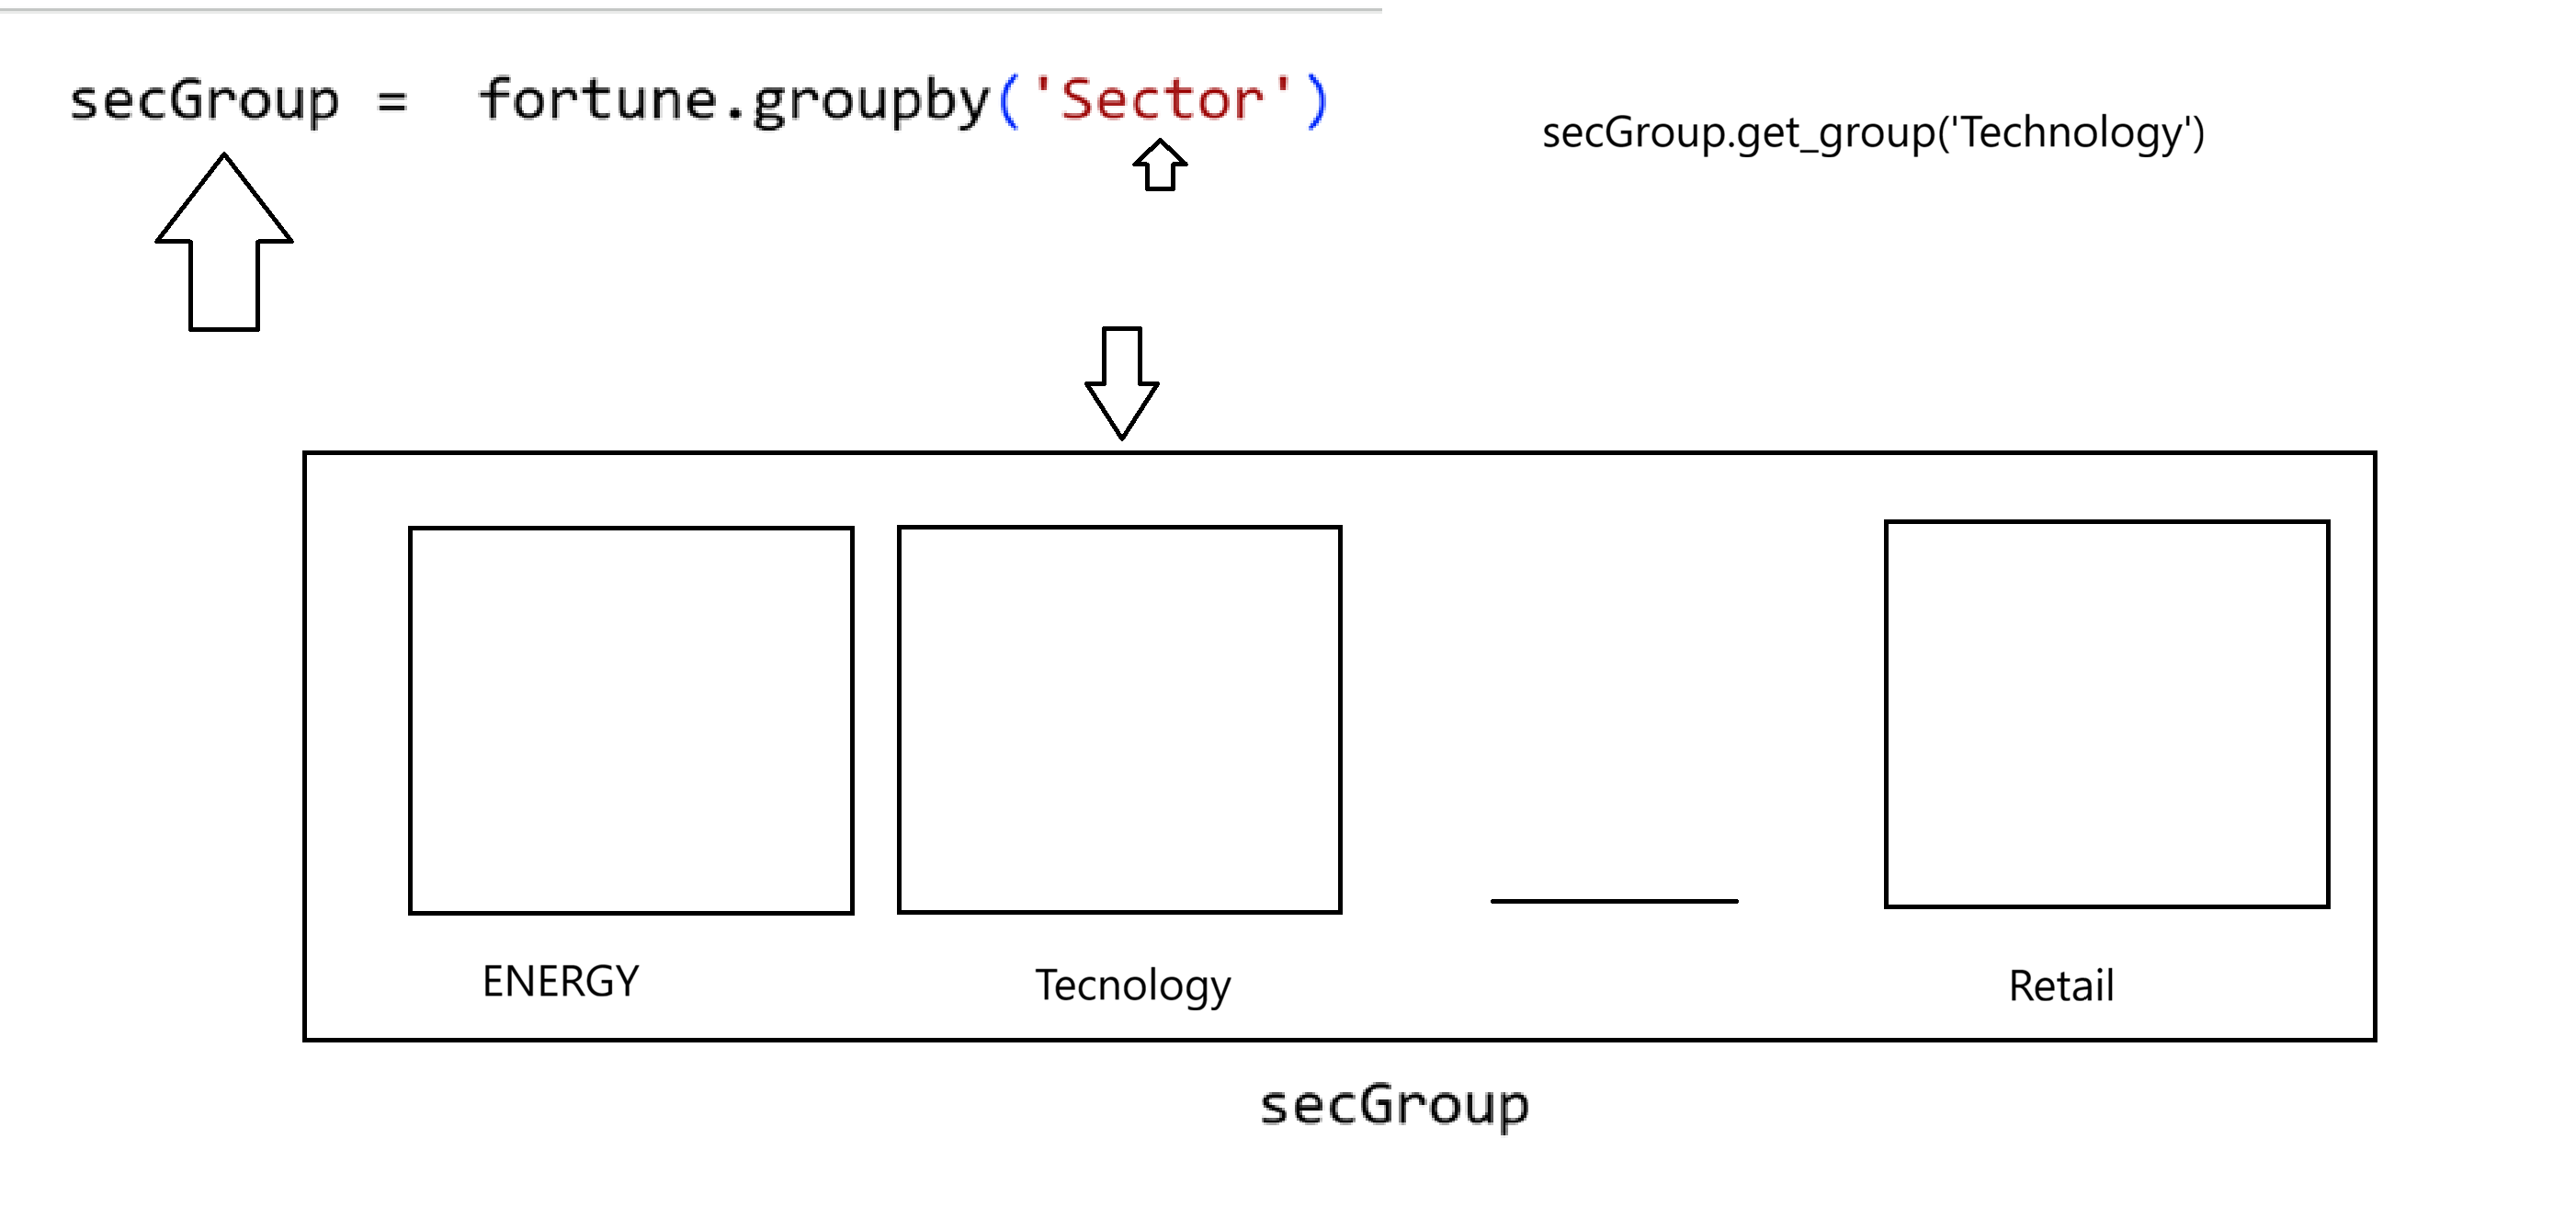

In [ ]:
secGroup

#.agg()
---------------
 Powerful Function

<pre>
input: dictionary

key : column
value : operation

In [ ]:
secGroup.agg(    {'Revenue' : 'sum' } )

,Revenue
Sector,
Aerospace & Defense,357940
Apparel,95968
Business Services,272195
Chemicals,243897
Energy,1517809
Engineering & Construction,153983
Financials,2217159
Food and Drug Stores,483769
"Food, Beverages & Tobacco",555967


In [ ]:
secGroup.agg(    {'Revenue' : 'sum'  , 'Profits' : ['max','min','sum','median','mean'] }  )

# groupingObject.agg(   {column: operation ,      column: [opr1,opr2,opr3]  }      )

Revenue Profits                        \
                                  sum     max    min     sum median   
Sector                                                                
Aerospace & Defense            357940    7608   -240   28742  566.5   
Apparel                         95968    3273     82    8236  233.0   
Business Services              272195    6328  -1481   28227  296.0   
Chemicals                      243897    7685   -816   22628  367.5   
Energy                        1517809   16150 -23119  -73447  188.5   
Engineering & Construction     153983     803   -155    5304  150.5   
Financials                    2217159   24442  -1194  260209  583.0   
Food and Drug Stores           483769    5237    -62   16759  192.0   
Food, Beverages & Tobacco      555967    7351   -253   51417  498.0   
Health Care                   1614707   18108   -458  106114  346.0   
Hotels, Resturants & Leisure   169546    5920  -1394   20697  195.0   
Household Products             234737    7036  -1149   14428  274.0   
Industrials                    497581    4833  -6126   20764  215.0   
Materials                      259145     991  -1642    4428  142.0   
Media                          220764    8382   -881   24347  151.0   
Motor Vehicles & Parts         482540    9687   -889   25898  233.0   
Retailing                     1465076   14694  -1243   47830  182.0   
Technology                    1377600   53394  -4359  180473  373.0   
Telecommunications             461834   17879   -271   48637  747.0   
Transportation                 408508    7610   -191   44169  392.0   
Wholesalers                    444800    1472   -502    8233  128.0   

                                           
                                     mean  
Sector                                     
Aerospace & Defense           1437.100000  
Apparel                        549.066667  
Business Services              553.470588  
Chemicals                      754.266667  
Energy                        -602.024590  
Engineering & Construction     204.000000  
Financials                    1872.007194  
Food and Drug Stores          1117.266667  
Food, Beverages & Tobacco     1195.744186  
Health Care                   1414.853333  
Hotels, Resturants & Leisure   827.880000  
Household Products             515.285714  
Industrials                    451.391304  
Materials                      102.976744  
Media                          973.880000  
Motor Vehicles & Parts        1079.083333  
Retailing                      597.875000  
Technology                    1769.343137  
Telecommunications            3242.466667  
Transportation                1226.916667  
Wholesalers                    205.825000

# Broadcasting
--------------------------------

enables Feature Engineering in EDA

In [ ]:
nba.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.00
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.00
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4842684.11
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.00
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.00


[Salary] - You are asked to convert salary into millions


In [ ]:
nba.Salary / 1000000

,Salary
0,7.730337
1,6.796117
2,4.842684
3,1.148640
4,5.000000
...,...
453,2.433333
454,0.900000
455,2.900000
456,0.947276


In [ ]:
def convertTomill( Sal ) :

  return f'{round(Sal / 1000000,2)} Mill.'

In [ ]:
# 7730337.00 -> 7.73 Mill

In [ ]:
nba['Salary(Mill)'] = nba.Salary.apply(    convertTomill  )

In [ ]:
nba.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Salary(Mill)
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.00,7.73 Mill.
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.00,6.8 Mill.
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4842684.11,4.84 Mill.
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.00,1.15 Mill.
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.00,5.0 Mill.


# Example that helps build confidence
--------------

In [ ]:
nba.head(3)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Salary(Mill)
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.00,7.73 Mill.
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.00,6.8 Mill.
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4842684.11,4.84 Mill.


# you are asked to populate a new column weightCategory and assign category as per details below
```
w > 220 overweight
w  between 180 and 220 normalweight
w < 180 underweight

In [ ]:
def getCategory( w ) :

  if w > 220 :
    return 'overweight'

  elif w >=180 and w<=220:
    return 'normalweight'

  else:
    return 'underweight'

In [ ]:
nba['weightCategory'] = nba.Weight.apply( getCategory )

In [ ]:
nba.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Salary(Mill),weightCategory
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.00,7.73 Mill.,normalweight
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.00,6.8 Mill.,overweight
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4842684.11,4.84 Mill.,normalweight
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.00,1.15 Mill.,normalweight
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.00,5.0 Mill.,overweight


In [ ]:
nba.weightCategory.value_counts()

,count
weightCategory,
overweight,223
normalweight,212
underweight,23


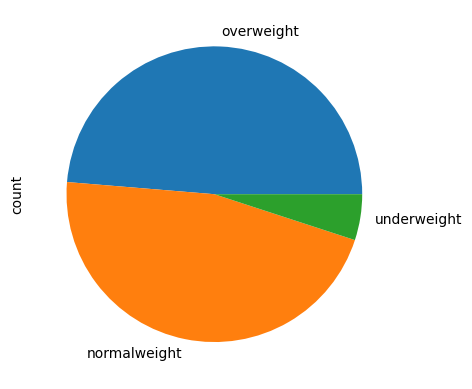

In [ ]:
nba.weightCategory.value_counts().plot(kind='pie');